# **SeeThru: Quantitative assessment of clearing efficacy**



### This programme is a semi-automated, easy-to-use pipeline which can:

 - Import a 3D image using `bioio`
 - measure pixel intensities of your sample in depth
 - counts cells in 3D using `Stardist`
 - visualise your data and save the results in a `.csv` 


### This data can be used to **quantify** the level of tissue scattering and availability of bioloigcal information in your data, allowing you to compare different optical clearing protocols.

# **Section 1: Image import, visualisation, and metadata**

In [2]:
#IMPORTING REQUIRED MODULES - these include funcitons in Python that help with data cleaning, processing, and visualisation


#image and metadata import
from bioio import BioImage
import bioio_bioformats

# data processing and computation
import numpy as np
import pandas as pd
from skimage import measure, filters
from cellpose import models
from stitching import stitch_2d_to_3d_fast
import math

# data visualisation and saving
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tf

#file handling
import glob
import os

## **Importing image and metadata**

#### The module `bioio` imports any image file type available under Bioformats ([see here for the full list](https://bio-formats.readthedocs.io/en/latest/supported-formats.html)), inclduing the relevant metadata.

#### The image is separated into the channel of interest, and the relevant metadata for analysis

In [ ]:
im_read = BioImage('./test_inputs/test_input.ome.tiff')  # reads file from relative path

"""
READING METADATA - key parameters to measure:
- image size in CYZX
- pixel resolution in X, Y, Z
"""


dims = [im_read.standard_metadata.image_size_c, im_read.standard_metadata.image_size_z, im_read.standard_metadata.image_size_y, im_read.standard_metadata.image_size_x] # dimensions of image in CZYX
x_res, y_res, z_res = im_read.physical_pixel_sizes.X, im_read.physical_pixel_sizes.Y, im_read.physical_pixel_sizes.Z # pulls resolution values from recorded metadata

print(f"Resolution of X (µm): {im_read.physical_pixel_sizes.X} \nResolution of Y (µm): {im_read.physical_pixel_sizes.Y} \nResolution of Z (µm): {im_read.physical_pixel_sizes.Z}") #prints out resolution in X,Y,Z

### **Dimension reduction**: SeeThru requires only one channel at a time - we recommend a nuclear channel (e.g. DAPI, Hoechst, TO-PRO-3) to get the most out of this pipeline

#### Don't forget - Python starts counting from 0! So channel 1 is 0, channel 2 is 1, etc...

In [ ]:
"""
DIMENSION REDUCTION:
Reduce down channels to only 1 (nuclear channel) and convert to numpy array for measurement/manipulation
"""


nuclear_channel_no = 0 # change this to the relevant channel number!

if dims[0] > 1: # check for number of channels
    im_nuclear = im_read.data[0][nuclear_channel_no]
else:
    im_nuclear = im_read.data[0][0]  #im_nuclear becomes a numpy array, removing the time and channel dimensions since they are unused


(-0.5, 998.5, 998.5, -0.5)

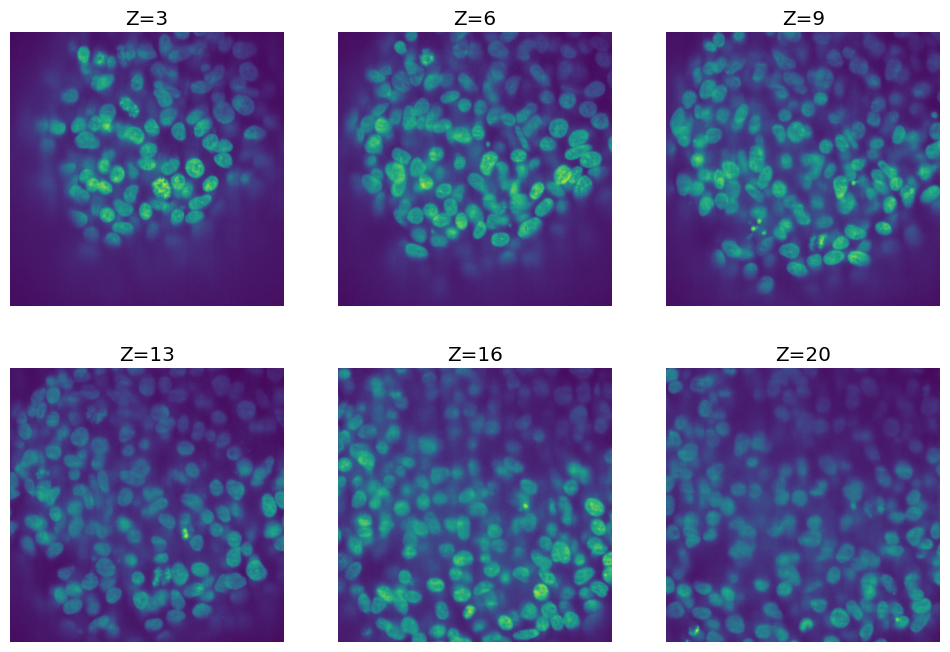

In [21]:
"""
Image 

Visualisation of slices in raw data
"""

fig, axs = plt.subplots(2, 3, figsize=(12,8))

axs[0,0].imshow(im_nuclear[int(len(im_nuclear) / 6)])
axs[0,0].set_title(f"Z={int(len(im_nuclear) / 6)}")
axs[0,0].axis('off')

axs[0,1].imshow(im_nuclear[2 *int(len(im_nuclear) / 6)])
axs[0,1].set_title(f"Z={int(2 * len(im_nuclear) / 6)}")
axs[0,1].axis('off')

axs[0,2].imshow(im_nuclear[3 * int(len(im_nuclear) / 6)])
axs[0,2].set_title(f"Z={3 * int(len(im_nuclear) / 6)}")
axs[0,2].axis('off')

axs[1,0].imshow(im_nuclear[4 * int(len(im_nuclear) / 6)])
axs[1,0].set_title(f"Z={int(4 *len(im_nuclear) / 6)}")
axs[1,0].axis('off')

axs[1,1].imshow(im_nuclear[int(5* len(im_nuclear) / 6)])
axs[1,1].set_title(f"Z={int(5 *len(im_nuclear) / 6)}")
axs[1,1].axis('off')


axs[1,2].imshow(im_nuclear[int(len(im_nuclear) - 1)])
axs[1,2].set_title(f"Z={int(len(im_nuclear))}")
axs[1,2].axis('off')

                        

### **Max Intensity Projections (MIP)**

### To be able to locate the sample within your image, it is best to use the MIP; with this, we can:
- #### find the midpoint of the sample in X and Y
- #### measure the area of the sample in X and Y, as a proxy for total sample volume

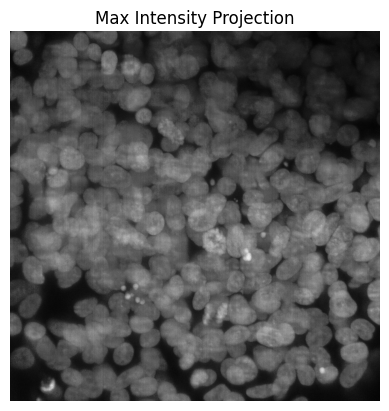

Sample midpoint: (473,538)


3232760322.py (20): Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
3232760322.py (22): Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [7]:
# producing Max Intensity Projection

mip = np.max(im_nuclear, axis=0)

plt.imshow(mip, cmap='gray')  # visualise MIP
plt.axis('off')
plt.title("Max Intensity Projection")
plt.show()

"""
Measuring the area of the MIP as a proxy for the volume of the sample
"""

mip_thresh = filters.threshold_li(mip)  #using segmentation to identify MIP from the background
binary_mip = mip >= mip_thresh

clean_labels = (binary_mip > 0).astype(np.uint8)
mip_props = measure.regionprops_table(clean_labels, mip, properties=['area', 'centroid']) # measures area of the MIP in px

mip_area = round(int(mip_props['area']) * (x_res * x_res),2) # converts area to microns squared

cx, cy = int(mip_props['centroid-1']),int(mip_props['centroid-0'])
print(f"Sample midpoint: ({cx},{cy})")

# **Section 2: Pixel intensity parameters**

### The simplest, easiest way to measure clearing is to look at changes in pixel intensity values with depth.

### SeeThru measures three main variables: the mean intensity, the signal-to-noise ratio, and the standard deviation of pixel intensities.

In [9]:
""""
PIXEL INTENSITY DATA:
    - inputs: image_3d (raw data), mask_3d (segmented binary mask of sample)
    - measures pixel intensity values of foreground (image_3d where mask_3d detects an object) and background
    - measures mean, standard deviation, SNR, returns in a dictionary
"""

def calculate_contrast_vs_depth(image_3d, mask_3d):
    n_slices = image_3d.shape[0]
    
    intensity_per_slice = [] # signal to background ratio
    snr_per_slice = [] # contrast to noise ratio
    std_per_slice= [] # signal - mean background intensitty
    
    for z in range(n_slices): # loops through every Z slice
        slice_img = image_3d[z]
        slice_mask = mask_3d[z]
        
        # skip if no object in this slice
        if not np.any(slice_mask):
            intensity_per_slice.append(np.nan)
            snr_per_slice.append(np.nan)
            std_per_slice.append(np.nan)
            continue
        
        # separate the pixels in the object and in the background
        object_pixels = slice_img[slice_mask]
        background_pixels = slice_img[~slice_mask]
        
        # calculating key parameters
        intensity_mean = np.mean(object_pixels)
        background = np.mean(background_pixels)
        bg_std = np.std(background_pixels)
        fg_std = np.std(object_pixels)
        
        #add to relevant lists
        intensity_per_slice.append(intensity_mean)
        snr_per_slice.append(intensity_mean / bg_std)
        std_per_slice.append(fg_std)
    
    # return parameters as a list
    return {
        'mean_intensity': np.array(intensity_per_slice),
        'snr': np.array(snr_per_slice),
        'std_dev': np.array(std_per_slice),
        'z_slice': np.arange(n_slices)
    }

### **Saving data in a `pandas DataFrame`**

### The data from your image is stored in a DataFrame using the `pandas` module - with a similar structure to a `.csv` file or `tibble` in R.

### We can add important metadata (such as the clearing, the depth in microns rather than just z-slice), and normalise the measured parameters.

In [11]:
"""
Run function and add relevant data to dataframe - allows comparison of key features later on
"""


mask_3d = im_nuclear >= filters.threshold_triangle(im_nuclear) # 3d binary mask to differentiate sample from background

# recording pixel values and intensities
stats_props = pd.DataFrame(calculate_contrast_vs_depth(im_nuclear, mask_3d))
stats_props['Clearing'] = 'PBS' # allows comparison later
stats_props['Depth (microns)'] = stats_props['z_slice'] * z_res

# normalising and correcting data
stats_props['normalised_mean'] = (stats_props['mean_intensity'] - np.min(stats_props['mean_intensity'])) / (np.max(stats_props['mean_intensity']) - np.min(stats_props['mean_intensity']))
stats_props['corrected_std'] = stats_props['std_dev'] / stats_props['mean_intensity']
stats_props['mip_area'] = mip_area

stats_props.tail() # visualisation of the last 5 rows of data

,mean_intensity,snr,std_dev,z_slice,Clearing,Depth (microns),normalised_mean,corrected_std,mip_area
15,2893.272305,7.838678,448.675329,15,PBS,30.0,0.215594,0.155075,16055.46
16,2888.953830,7.906866,453.930003,16,PBS,32.0,0.201095,0.157126,16055.46
17,2887.448556,7.956026,458.981959,17,PBS,34.0,0.196042,0.158958,16055.46
18,2868.966489,7.924159,469.303488,18,PBS,36.0,0.133993,0.163579,16055.46
19,2829.055331,7.911848,437.397933,19,PBS,38.0,0.000000,0.154609,16055.46


Text(0, 0.5, 'Corrected Std Dev')

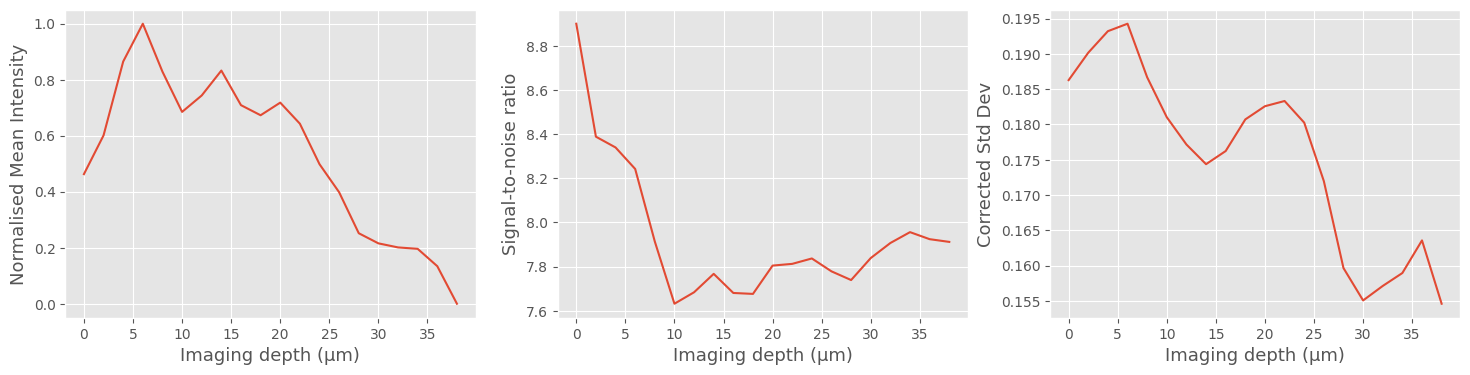

In [12]:
# visualising results with seaborn

plt.style.use("ggplot")

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot( # visualise distribution of mean intensity
    data=stats_props,
    x='Depth (microns)',
    y='normalised_mean',
    ax=axs[0]
)

sns.lineplot( #visualise distribution of signal-to-noise ratio
    data=stats_props,
    x='Depth (microns)',
    y='snr',
    ax=axs[1]
)

sns.lineplot(
    data=stats_props, #visualise distribution of std dev, corrected for changes in intensity per slice
    x='Depth (microns)',
    y='corrected_std',
    ax=axs[2]
)

axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

axs[0].set_xlabel("Imaging depth (µm)", fontsize=13)
axs[1].set_xlabel("Imaging depth (µm)", fontsize=13)
axs[2].set_xlabel("Imaging depth (µm)", fontsize=13)

axs[0].set_ylabel("Normalised Mean Intensity", fontsize=13)
axs[1].set_ylabel("Signal-to-noise ratio", fontsize=13)
axs[2].set_ylabel("Corrected Std Dev", fontsize=13)

# **Section 3: Nuclei segmentation**

### For nuclei segmentation, we use the deep learning algorithm `Cellpose` to detect nuclei per slice. We can then stitch 2D objects into 3D using an __Intersection-of-Union (IoU) algorithm__.

### From this, we can measure each nuclei and gain insight into how these values change with depth!

In [13]:
"""
CELL COUNTING:
    - cell segmentation done in 2D with Cellpose
    - IoU stitching ('stitching.py') allows conversion of 2D into 3D
    - 3D segmentations saved as a numpy array
"""


model = models.CellposeModel(gpu=True)
nuc_labels = np.empty(im_nuclear.shape)


for i in range(len(im_nuclear)):
    slice = im_nuclear[i]
    print(f'Detecting nuclei in slice {(i + 1)} of {im_nuclear.shape[0]}')

    masks, flows, styles = model.eval(slice, flow_threshold=0.4, cellprob_threshold=0.0)
    nuc_labels[i] = masks

    print(f"  -> Detected {nuc_labels[i].max()} objects")


segmentation_3d, stats = stitch_2d_to_3d_fast(nuc_labels) # stitch 2d segmentations into 3D objects with IoU-based stitching

Detecting nuclei in slice 1 of 20
  -> Detected 40.0 objects
Detecting nuclei in slice 2 of 20
  -> Detected 58.0 objects
Detecting nuclei in slice 3 of 20
  -> Detected 64.0 objects
Detecting nuclei in slice 4 of 20
  -> Detected 73.0 objects
Detecting nuclei in slice 5 of 20
  -> Detected 83.0 objects
Detecting nuclei in slice 6 of 20
  -> Detected 102.0 objects
Detecting nuclei in slice 7 of 20
  -> Detected 115.0 objects
Detecting nuclei in slice 8 of 20
  -> Detected 115.0 objects
Detecting nuclei in slice 9 of 20
  -> Detected 127.0 objects
Detecting nuclei in slice 10 of 20
  -> Detected 132.0 objects
Detecting nuclei in slice 11 of 20
  -> Detected 129.0 objects
Detecting nuclei in slice 12 of 20
  -> Detected 152.0 objects
Detecting nuclei in slice 13 of 20
  -> Detected 151.0 objects
Detecting nuclei in slice 14 of 20
  -> Detected 148.0 objects
Detecting nuclei in slice 15 of 20
  -> Detected 163.0 objects
Detecting nuclei in slice 16 of 20
  -> Detected 168.0 objects
Detect

### **Saving segmentations as an output** - SeeThru saves the channel of interest with the Cellpose segmentations as a channel, so you can validate how the segmentations look and fix if necessary!

In [14]:
"""
Save segmentations as a tiff file for qualitative check
"""
result = np.stack([im_nuclear, segmentation_3d], axis=0)
result = result.astype(np.uint16) #reduce file size
result = np.transpose(result, (1,0,2,3))

# Create outputs directory
output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)

# Save with metadata
tf.imwrite(
    './outputs/segmentations.tiff',
    result,
    imagej=True,          # writes ImageJ hyperstack metadata
    metadata={'axes': 'ZCYX'}
)

(-0.5, 998.5, 998.5, -0.5)

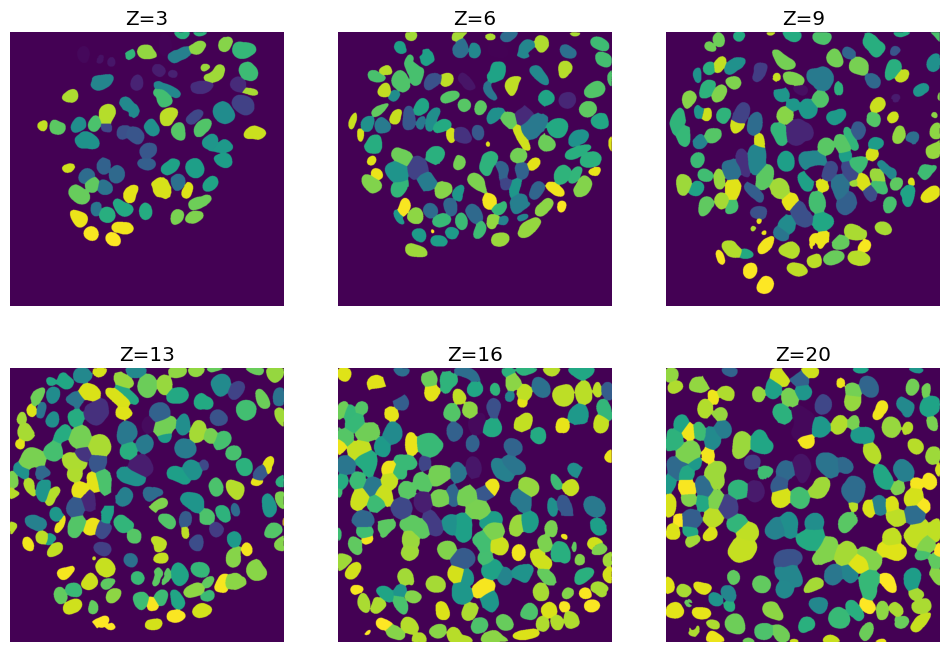

In [15]:
"""
visualise segmentation results
"""

fig, axs = plt.subplots(2, 3, figsize=(12,8))

axs[0,0].imshow(segmentation_3d[int(len(segmentation_3d) / 6)])
axs[0,0].set_title(f"Z={int(len(segmentation_3d) / 6)}")
axs[0,0].axis('off')

axs[0,1].imshow(segmentation_3d[2 *int(len(segmentation_3d) / 6)])
axs[0,1].set_title(f"Z={int(2 * len(segmentation_3d) / 6)}")
axs[0,1].axis('off')

axs[0,2].imshow(segmentation_3d[3 * int(len(segmentation_3d) / 6)])
axs[0,2].set_title(f"Z={3 * int(len(segmentation_3d) / 6)}")
axs[0,2].axis('off')

axs[1,0].imshow(segmentation_3d[4 * int(len(segmentation_3d) / 6)])
axs[1,0].set_title(f"Z={int(4 *len(segmentation_3d) / 6)}")
axs[1,0].axis('off')

axs[1,1].imshow(segmentation_3d[int(5* len(segmentation_3d) / 6)])
axs[1,1].set_title(f"Z={int(5 *len(segmentation_3d) / 6)}")
axs[1,1].axis('off')


axs[1,2].imshow(segmentation_3d[int(len(segmentation_3d) - 1)])
axs[1,2].set_title(f"Z={int(len(segmentation_3d))}")
axs[1,2].axis('off')


In [16]:
"""
Nuclei data:
    - Using skimage.measure to extract key parameters from numpy array containing 3D cell segmentations
    - adding relevant metadata to the dictionary
    - convert data into a pandas DataFrame for manipulation and visualisation
"""

nuclei_props = measure.regionprops_table(segmentation_3d.astype(np.int64), im_nuclear, properties=['area', 'mean_intensity','centroid', 'inertia_tensor_eigvals', 'bbox'])  # measures properties per 3D nuclei
nuclei_props['Depth (microns)'] = nuclei_props['centroid-0'] * z_res
nuclei_props['Clearing'] = 'PBS'  # change with the clearing protocol used
nuclei_props['volume (µm3)'] = nuclei_props['area'] * x_res * y_res * z_res
nuclei_props['log(area)'] = np.log10(nuclei_props['volume (µm3)']) # puts volume on log scale to allow better fitting

nuclei_props = pd.DataFrame(nuclei_props)
nuclei_props.head()

,area,mean_intensity,centroid-0,centroid-1,centroid-2,inertia_tensor_eigvals-0,inertia_tensor_eigvals-1,inertia_tensor_eigvals-2,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,Depth (microns),Clearing,volume (µm3),log(area)
0,25403.0,1848.368775,3.037870,58.698697,573.978270,728.602033,486.757680,248.960044,0,8,541,7,100,622,6.075739,PBS,1190.873060,3.075865
1,10718.0,3251.394477,2.834671,83.404180,266.456802,373.935878,255.497466,122.260933,0,51,242,6,122,291,5.669341,PBS,502.451579,2.701094
2,7075.0,2537.084240,0.439576,95.503039,475.768057,576.171816,313.692002,262.970666,0,61,441,2,132,513,0.879152,PBS,331.670547,2.520707
3,8437.0,1485.541543,0.489273,98.552803,679.113903,793.009799,590.051238,203.453966,0,60,637,2,137,727,0.978547,PBS,395.520057,2.597169
4,7394.0,2964.961049,1.039086,106.020016,330.917501,374.856539,212.215438,164.429894,0,77,306,4,142,370,2.078171,PBS,346.625021,2.539860


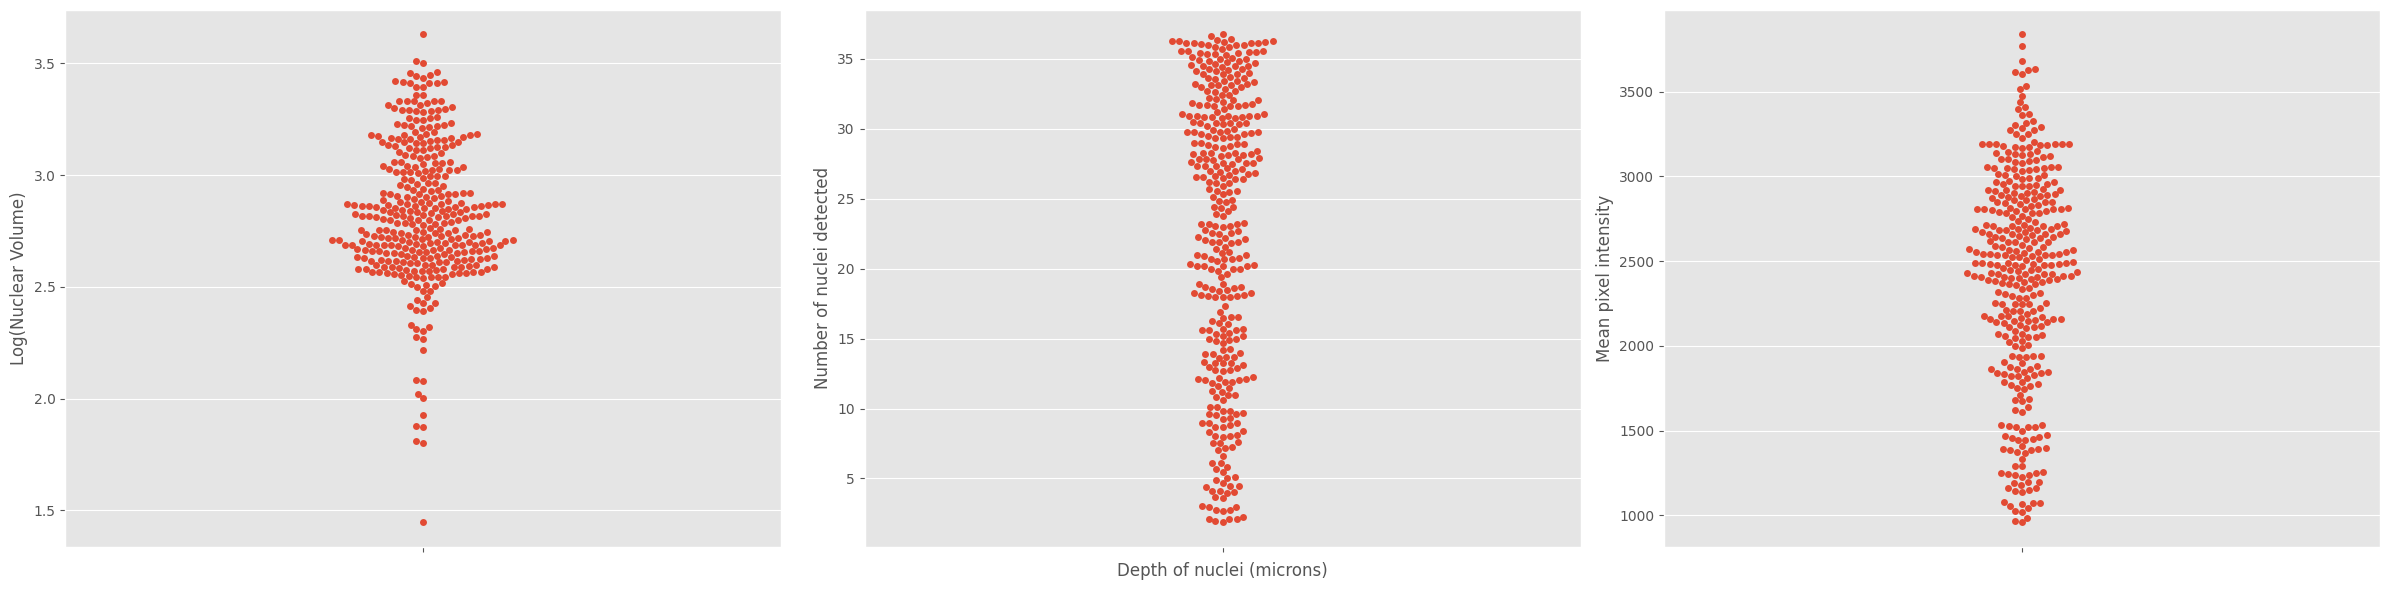

In [17]:
"""
Visualisation and QC of measured nuclei data and parameters:
    - removing junk detections with QC check
    - visualising data with seaborn
"""

clean_nuclei_props = nuclei_props[(nuclei_props['bbox-3'] - nuclei_props['bbox-0']) > 2] # QC Check on nuclei dimensions in X/Y and Z

fig, axs = plt.subplots(1, 3, figsize=(24,6))

sns.swarmplot(
    data=clean_nuclei_props,
    y='log(area)',
    ax=axs[0]
)

sns.swarmplot(
    data=clean_nuclei_props,
    y='Depth (microns)',
    ax=axs[1]
)

sns.swarmplot(
    data=clean_nuclei_props,
    y='mean_intensity',
    ax=axs[2]
)

axs[0].set_ylabel("Log(Nuclear Volume)")

axs[1].set_xlabel("Depth of nuclei (microns)")
axs[1].set_ylabel("Number of nuclei detected")

axs[2].set_ylabel("Mean pixel intensity")

plt.tight_layout()

In [18]:
# measuring percentage of detections which passed bounding box QC checks

def clean_data_percentage(raw_df, clean_df):

    raw_detections = len(raw_df.index)
    clean_detections = len(clean_df.index)

    percentage = round((100*(clean_detections / raw_detections)),2)

    return percentage


print(f"About {clean_data_percentage(nuclei_props, clean_nuclei_props)}% of initial detections are true nuclei detections")

About 75.36% of initial detections are true nuclei detections


In [ ]:
# saving data into .csv files
stats_props.to_csv("./outputs/test-stats-data.csv")  # saves statistical parameters
clean_nuclei_props.to_csv("./outputs/test-cells-data.csv")  # saves nuclei count and QC parameters